In [1]:
# Import pandas for data handling (tables, CSV files)
import pandas as pd  

# Import numpy for numerical operations
import numpy as np 

# Import matplotlib for data visualization
import matplotlib.pyplot as plt 

# Import seaborn for graph representations
import seaborn as sns 

# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split  

# Import CountVectorizer to convert text into numerical features
from sklearn.feature_extraction.text import CountVectorizer  

# Import Naive Bayes model for text classification
from sklearn.naive_bayes import MultinomialNB  

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix  

# CountVectorizer already imported above (duplicate import - not needed again)
from sklearn.feature_extraction.text import CountVectorizer  

In [2]:
# Load dataset from CSV file into a DataFrame
df = pd.read_csv('synthetic_text_data.csv')
df.head(20)

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology
5,Political debates are becoming more heated as ...,Politics
6,Tech companies are investing heavily in artifi...,Technology
7,"The summer Olympics are fast approaching, and ...",Sports
8,Music festivals are back this year with global...,Entertainment
9,The rise of self-driving cars is changing the ...,Technology


In [3]:
df.shape

(85, 2)

In [4]:
# Check missing values
df.isnull().sum()

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Convert text to lowercase (important for NLP)
df['text'] = df['text'].str.lower()

# Remove extra spaces
df['text'] = df['text'].str.strip()

# Check final shape
print(df.shape)

(85, 2)


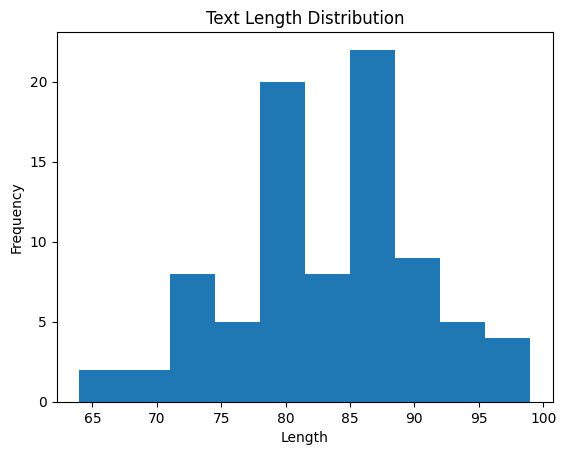

In [5]:
# Create new column for text length
df['text_length'] = df['text'].apply(len)

# Plot distribution
plt.figure()
plt.hist(df['text_length'])
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

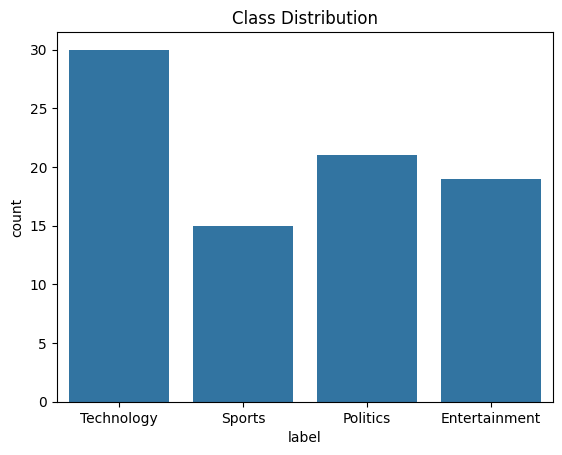

In [6]:
# Create a count plot to show the distribution of each class in the 'label' column
sns.countplot(x='label', data=df)

# Set the title of the plot
plt.title("Class Distribution")

# Display the plot
plt.show()

In [7]:
from collections import Counter

# Combine all text into one string and split into words
all_words = " ".join(df['text']).split()

# Count frequency of each word
word_freq = Counter(all_words)

# Display top 10 most common words
print(word_freq.most_common(10))


[('the', 61), ('are', 55), ('to', 30), ('in', 27), ('and', 23), ('of', 21), ('political', 18), ('new', 14), ('is', 13), ('with', 12)]


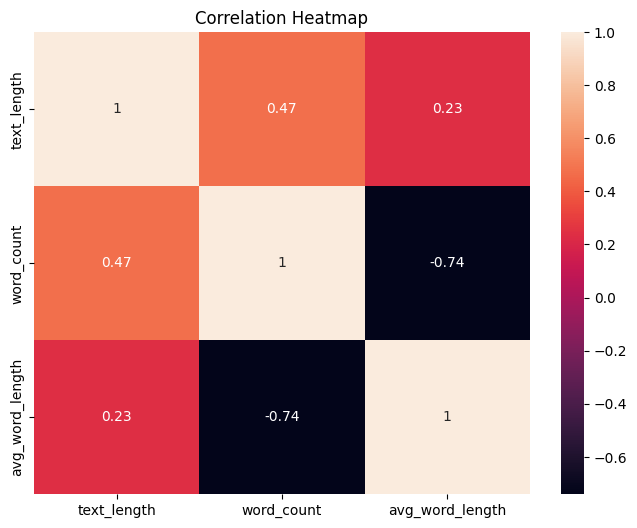

In [8]:
# Har text ki length calculate ki ja rahi hai
df['text_length'] = df['text'].apply(len)

# Word count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Average word length
df['avg_word_length'] = df['text_length'] / df['word_count']

# Plot ka size set kiya ja raha hai (width=8, height=6)
plt.figure(figsize=(8,6))

# Correlation matrix ka heatmap banaya ja raha hai
# annot=True ka matlab hai values bhi boxes ke andar show hongi
sns.heatmap(df[['text_length','word_count','avg_word_length']].corr(), annot=True)

# Graph ka title set kiya gaya hai
plt.title("Correlation Heatmap")

# Graph display kar diya gaya hai
plt.show()

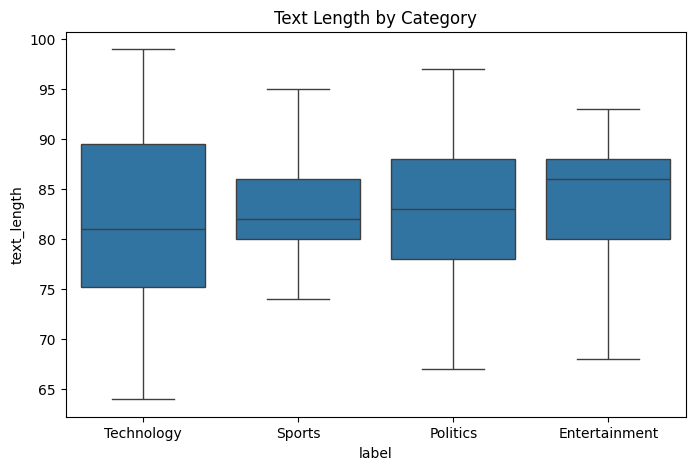

In [9]:
# Plot size set kiya gaya hai
plt.figure(figsize=(8,5))

# Har category ke text length ka comparison plot ho raha hai
sns.boxplot(x='label', y='text_length', data=df)

# Title set kiya gaya hai
plt.title("Text Length by Category")

# Graph show
plt.show()

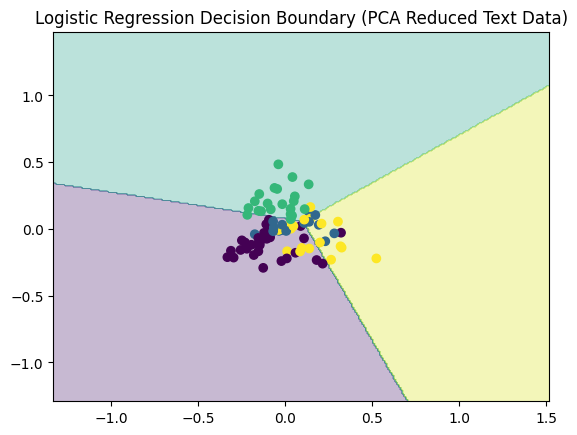

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Convert text data into numerical features using TF-IDF
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df['text'])

X_tfidf_dense = X_tfidf.toarray().astype(float)

# Reduce high-dimensional TF-IDF features to 2D using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X_tfidf_dense)

# Target labels
y = pd.factorize(df['label'])[0]

# Initialize Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X, y)

# Create meshgrid for decision boundary visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Predict class for each point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape predictions back to grid shape
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual data points
plt.scatter(X[:, 0], X[:, 1], c=pd.factorize(y)[0])

plt.title("Logistic Regression Decision Boundary (PCA Reduced Text Data)")
plt.show()

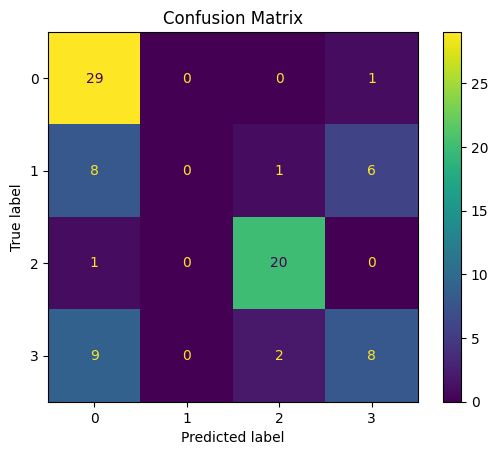

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [12]:
# Select the 'text' column (input features - emails/messages)
X = df['text']

# Select the 'target' column (target/output)
y = df['label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # Input features (text) and labels
    test_size=0.2,     # 20% data for testing, 80% for training
    random_state=42    # Ensures same split every time (reproducibility)
)

In [13]:
# Create CountVectorizer object (used to convert text into numbers)
vectorizer = CountVectorizer()

# Learn vocabulary from training data and convert text into numerical vectors
X_train_vectorized = vectorizer.fit_transform(X_train)

# Transform test data using the same learned vocabulary (no fitting here)
X_test_vectorized = vectorizer.transform(X_test)

In [14]:
# Create the Naive Bayes model (MultinomialNB is best for text data)
model = MultinomialNB()

# Train the model using vectorized training data
model.fit(X_train_vectorized, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
# Train the model using training data
model.fit

<bound method _BaseDiscreteNB.fit of MultinomialNB()>

In [16]:
# Use trained model to make predictions on test data
y_pred = model.predict(X_test_vectorized)

Accuracy: 88.23529411764706%


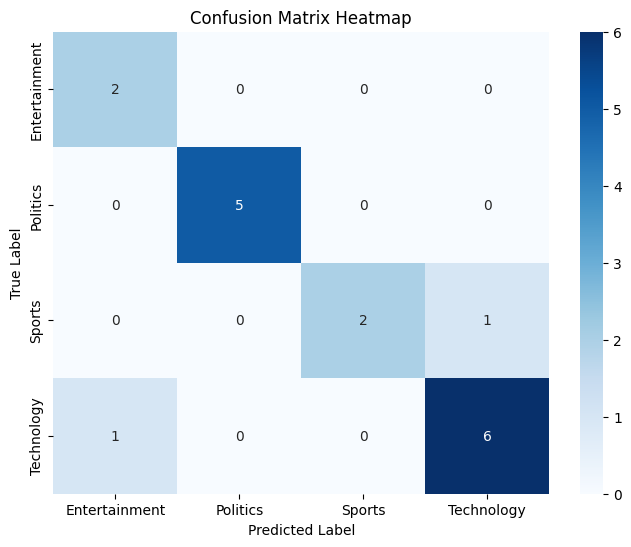

In [17]:
# Calculate the accuracy of the model (how many predictions are correct)
accuracy = accuracy_score(y_test, y_pred)

# Generate the confusion matrix (comparison of actual vs predicted values)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print the accuracy as a percentage
print(f'Accuracy: {accuracy *100}%')

# Get unique class labels (e.g., spam / not spam)
class_labels = np.unique(y_test)

# Set the size of the plot
plt.figure(figsize=(8, 6))

# Create a heatmap of the confusion matrix
# annot=True -> display numbers inside the boxes
# fmt='d' -> show values as integers
# cmap='Blues' -> use blue color theme
# xticklabels -> labels for predicted values (x-axis)
# yticklabels -> labels for actual values (y-axis)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

# Set the title of the plot
plt.title('Confusion Matrix Heatmap')

# Label for x-axis (predicted values)
plt.xlabel('Predicted Label')

# Label for y-axis (actual values)
plt.ylabel('True Label')

# Display the plot
plt.show()

In [18]:
# Define a sample input sentence (text to be classified)
user_input = ("I love artificial intelligence and machine learning")

# Convert the input text into numerical form using the trained vectorizer
# (same transformation used during training)
user_input_vectorized = vectorizer.transform([user_input])

# Use the trained model to predict the category/label of the input text
predicted_label = model.predict(user_input_vectorized)

# Print the predicted category of the input text
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Technology' category.
